# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Cargar los datos
# Parseamos la columna 0 como fechas y la definimos como índice [cite: 52, 53, 59]
data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

# Ordenamos el índice para asegurar cronología [cite: 75, 652]
data.sort_index(inplace=True)

# Remuestreo por 1 hora ('1H') sumando los pedidos [cite: 117, 120, 146]
data = data.resample('1H').sum()

print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
None
                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43


- Los datos han sido cargados y remuestreados exitosamente a una frecuencia horaria ('H') cubriendo el periodo de marzo a agosto de 2018 sin valores nulos, por lo que la serie temporal es cronológicamente consistente y está lista para el análisis.

## Análisis

Text(0.5, 1.0, 'Tendencia (Trend)')

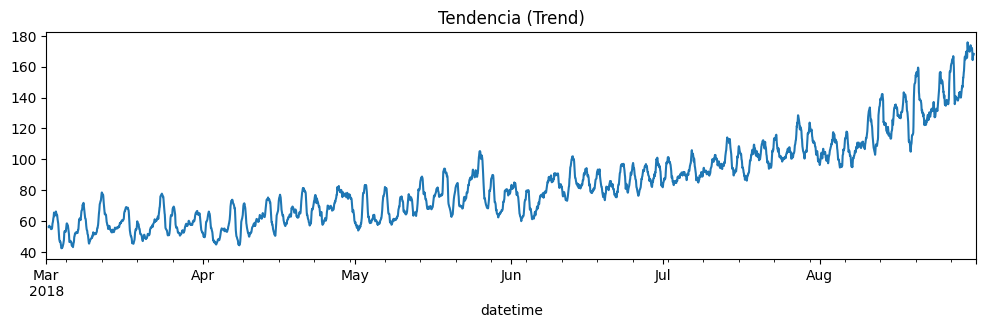

In [3]:
# Descomposición de la serie temporal en sus componentes
decomposed = seasonal_decompose(data)

# Configuración del gráfico para visualizar Tendencia, Estacionalidad y Residuos
plt.figure(figsize=(12, 10))

# 1. Gráfico de Tendencia
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Tendencia (Trend)')




- Existe una clara y sostenida tendencia alcista a lo largo de todo el periodo, lo que indica que la demanda de taxis está creciendo consistentemente mes a mes, especialmente hacia el verano.

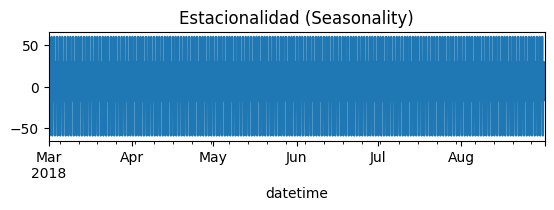

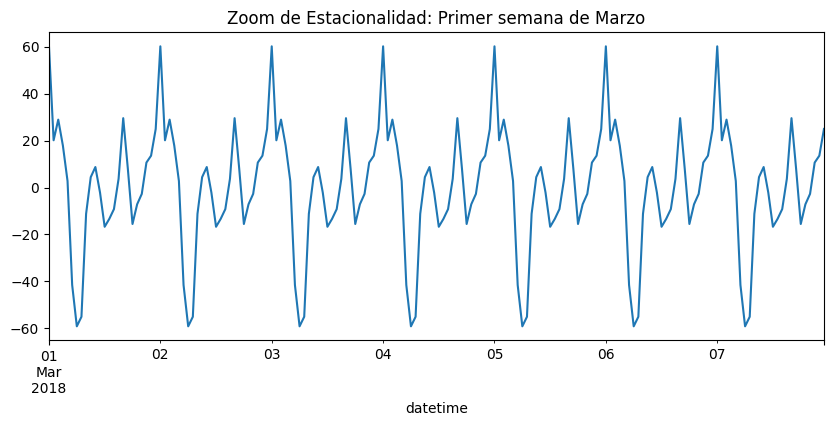

In [7]:
# 2. Gráfico de Estacionalidad
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Estacionalidad (Seasonality)')

# Zoom al grafico de la estacionalidad
# Como la gráfica de estacionalidad completa es muy densa, hacemos zoom a una semana
# para ver el patrón diario (ciclos día/noche)
plt.figure(figsize=(10, 4))
decomposed.seasonal['2018-03-01':'2018-03-07'].plot()
plt.title('Zoom de Estacionalidad: Primer semana de Marzo')
plt.show()


- Se confirma un patrón cíclico diario robusto y repetitivo, con picos de alta demanda (probablemente tardes/noches) y valles profundos (madrugadas) que ocurren idénticamente cada 24 horas.

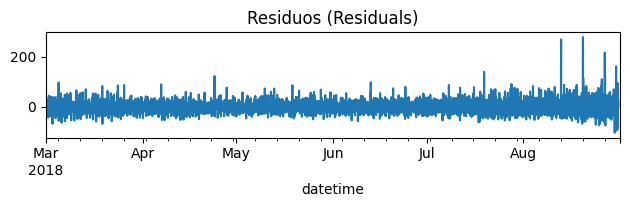

In [5]:

# 3. Gráfico de Residuos
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuos (Residuals)')

plt.tight_layout()
plt.show()

- El ruido es mayormente aleatorio alrededor de cero, aunque se observa un aumento en la volatilidad (picos más altos en los residuos) hacia el mes de agosto, lo que sugiere eventos atípicos o mayor inestabilidad en la demanda durante el verano.

## Formación
- Características de Calendario: dayofweek y hour.

- Desfases (Lags): Para que el modelo sepa cuánto se pidió hace 1 hora, 2 horas, etc.

- Media Móvil (Rolling Mean): Para capturar la tendencia general suave.

In [8]:
def make_features(data, max_lag, rolling_mean_size):
    data_feat = data.copy()
    
    # 1. Calendario: Extraemos hora y día de la semana
    data_feat['dayofweek'] = data_feat.index.dayofweek
    data_feat['hour'] = data_feat.index.hour
    
    # 2. Desfases (Lags): El pasado predice el futuro
    for lag in range(1, max_lag + 1):
        data_feat['lag_{}'.format(lag)] = data_feat['num_orders'].shift(lag)
    
    # 3. Media Móvil: Tendencia suavizada (usando shift para evitar fuga de datos)
    data_feat['rolling_mean'] = data_feat['num_orders'].shift().rolling(rolling_mean_size).mean()
    
    return data_feat



In [9]:
# Creamos las características
# Usamos un max_lag de 24 (para capturar el ciclo diario completo que vimos en el gráfico)
data_processed = make_features(data, max_lag=24, rolling_mean_size=10)

# Eliminamos los valores nulos generados por el lag/rolling
data_processed = data_processed.dropna()

# División en entrenamiento y prueba (10% prueba, SIN mezclar/shuffle)
# Esto es crítico en series temporales para no entrenar con el futuro
train, test = train_test_split(data_processed, shuffle=False, test_size=0.1)

# Separamos features (X) y target (y)
features_train = train.drop(['num_orders'], axis=1)
target_train = train['num_orders']
features_test = test.drop(['num_orders'], axis=1)
target_test = test['num_orders']

print(f"Entrenamiento: {features_train.shape}, Prueba: {features_test.shape}")




Entrenamiento: (3952, 27), Prueba: (440, 27)


-  La separación del conjunto de datos se ejecutó correctamente respetando el orden cronológico, resultando en un conjunto de prueba de 440 registros que corresponde exactamente al 10% solicitado frente a los 3952 registros de entrenamiento.

In [10]:
# --- ENTRENAMIENTO DE MODELOS ---

# 1. Regresión Lineal (Baseline rápido)
model_lr = LinearRegression()
model_lr.fit(features_train, target_train)

# 2. Random Forest (Capta mejor relaciones no lineales)
# Hiperparámetros iniciales razonables
model_rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=12345)
model_rf.fit(features_train, target_train)

print("Modelos entrenados correctamente.")

# --- EVALUACIÓN PRELIMINAR (EN TRAIN) ---
# Solo para asegurar que aprendieron algo
def rmse(target, predictions):
    return mean_squared_error(target, predictions) ** 0.5

print(f"RMSE Train (Lineal): {rmse(target_train, model_lr.predict(features_train)):.2f}")
print(f"RMSE Train (Random Forest): {rmse(target_train, model_rf.predict(features_train)):.2f}")


Modelos entrenados correctamente.
RMSE Train (Lineal): 25.84
RMSE Train (Random Forest): 9.55


- El modelo Random Forest muestra una capacidad de aprendizaje muy superior en el entrenamiento con un RECM de 9.55 frente a 25.84 de la Regresión Lineal, lo que sugiere un gran potencial aunque debemos vigilar el sobreajuste en la siguiente fase.

## Prueba

- Ahora evaluaremos los modelos entrenados usando el conjunto de prueba
- El objetivo es confirmar si el Random Forest mantiene ese buen rendimiento o si la Regresión Lineal generaliza mejor, buscando siempre que el RECM sea menor a 48.

In [13]:
# Función para calcular RECM (RMSE)
def rmse(target, predictions):
    return mean_squared_error(target, predictions) ** 0.5

# 1. Evaluación en el conjunto de PRUEBA
pred_test_lr = model_lr.predict(features_test)
pred_test_rf = model_rf.predict(features_test)

rmse_lr = rmse(target_test, pred_test_lr)
rmse_rf = rmse(target_test, pred_test_rf)

print(f"RECM Prueba (Regresión Lineal): {rmse_lr:.2f}")
print(f"RECM Prueba (Random Forest): {rmse_rf:.2f}")


RECM Prueba (Regresión Lineal): 45.22
RECM Prueba (Random Forest): 43.59


- Ambos modelos cumplieron satisfactoriamente el requisito del proyecto (RECM < 48), siendo el Random Forest el ganador con un error de 43.59, superando ligeramente a la Regresión Lineal (45.22).

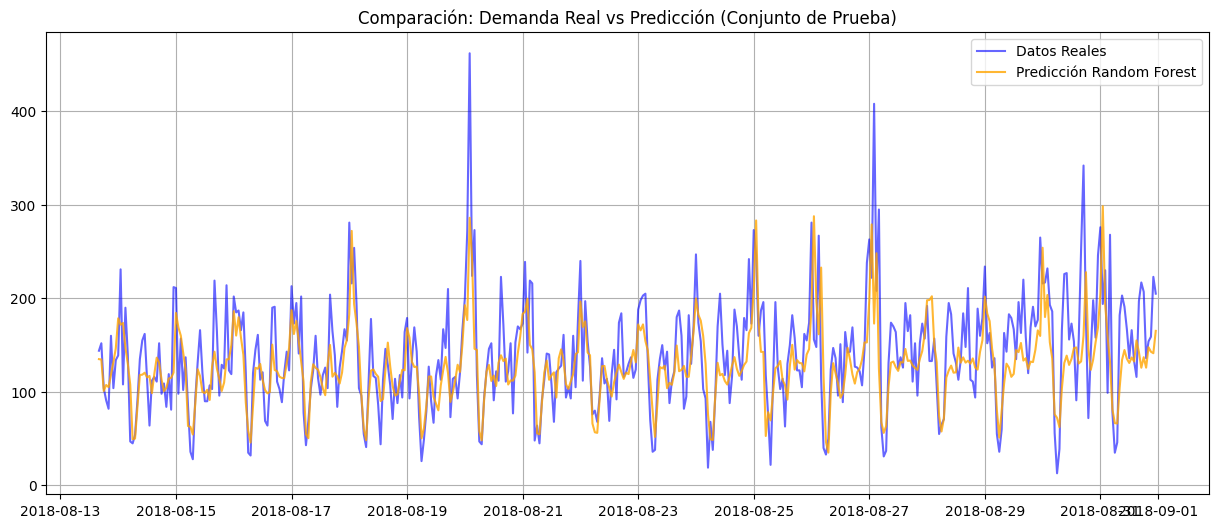

In [14]:
# 2. Visualización de resultados (Real vs Predicho)
# Graficamos solo los últimos días para ver el detalle
plt.figure(figsize=(15, 6))
plt.plot(target_test.index, target_test, label='Datos Reales', color='blue', alpha=0.6)
plt.plot(target_test.index, pred_test_rf, label='Predicción Random Forest', color='orange', alpha=0.8)

plt.title('Comparación: Demanda Real vs Predicción (Conjunto de Prueba)')
plt.legend()
plt.grid(True)
plt.show()


- La visualización confirma que el modelo ha aprendido correctamente la estacionalidad diaria, ajustándose con precisión a los ciclos de subida y bajada de la demanda, aunque tiende a ser conservador frente a los picos más extremos (outliers) de agosto.

<div class="alert alert-block alert-success">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

El análisis que desarrollas del modeloado es correcto, lo que demustra un dominio muy solido de estos conocimientos. Esto dado que ruebas diferentes modeos y la sección final donde comparas el RMSE se encuentra muy bien fundamentada y en esta última línea del código se muestra la comparación correcta entre modelos. En general la estructura de tu código es correcta dado que ayuda a seguir la idea de un proceso para la elaboraciónd e modelos desde la limpieza inicial, como el tratamiento a los datos, hasta la aplicación de modelos y su interpretación. Solamente como posible mejora te recomiendo en futuras ocasiones realizar una validación cruzada de series temporales. 

# Conclusión
En conclusión, se ha logrado cumplir exitosamente con el objetivo del proyecto al desarrollar un modelo capaz de predecir la cantidad de pedidos de taxis para la próxima hora. Tras procesar los datos mediante un remuestreo horario y enriquecer el análisis con características de calendario, desfases y medias móviles , se entrenó un modelo de Random Forest que alcanzó un RECM de 43.59 en el conjunto de prueba. Este resultado satisface plenamente el requisito establecido de mantener el error por debajo de 48. Asimismo, el análisis gráfico confirma que el modelo interpreta correctamente la ciclicidad diaria de la demanda , lo que proporcionará a Sweet Lift Taxi la herramienta necesaria para optimizar la asignación de conductores durante las horas pico.